# 🌍 Global Terrorism EDA — The Human & Economic Cost of War

## 📌 Project Overview

This project performs **Exploratory Data Analysis (EDA)** on the 
**Global Terrorism Database (GTD)** — one of the most comprehensive 
open-source datasets on terrorist attacks worldwide from **1970 to 2017**.

The dataset contains **1,81,691 attacks** across **205 countries** 
with **135 features** per incident.

---

## 🎯 Objective

> *"To understand the devastating human and economic impact of terrorism 
> on ordinary people — and why the world needs peace."*

Through data, we will uncover:
- 📈 How terrorism grew over 50 years
- 🌍 Which regions and countries suffered the most
- 💀 The true human cost — lives lost and wounded
- 💰 The economic destruction left behind
- 🕊️ What this data tells us about the need for world peace

---

*"War does not determine who is right — only who is left."*
*— Bertrand Russell*

---

## Step 1 — Import Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

plt.rcParams['figure.figsize'] = (12, 5)

## Step 2 — Load Data

In [4]:
# Step 2 — Load Data

df = pd.read_csv("globalterrorismdb_0718dist.csv", 
                 encoding='latin1',
                 low_memory=False)

print("Data Loaded Successfully!")
print("Shape:", df.shape)

Data Loaded Successfully!
Shape: (181691, 135)


## Step 3 — First Look at the Data

In [7]:
df.head()


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [15]:
# Shape of dataset
print("=== Shape ===")
print(df.shape)

=== Shape ===
(181691, 135)


In [16]:
# Column names and datatypes
print("=== Info ===")
df.info()

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [17]:
# Statistical summary
print("=== Statistical Summary ===")
df.describe()

=== Statistical Summary ===


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# Missing values
print("=== Missing Values ===")
df.isnull().sum()

=== Missing Values ===


eventid            0
iyear              0
imonth             0
iday               0
approxdate    172452
               ...  
INT_LOG            0
INT_IDEO           0
INT_MISC           0
INT_ANY            0
related       156653
Length: 135, dtype: int64

## Step 4 — Drop Unnecessary Columns

In [19]:
# Step 4 — Drop Unnecessary Columns

# Keeping only relevant columns
columns_to_keep = [
    'iyear',           # Year of attack
    'imonth',          # Month of attack
    'country_txt',     # Country
    'region_txt',      # World Region
    'attacktype1_txt', # Type of attack
    'targtype1_txt',   # Who was targeted
    'weaptype1_txt',   # Weapon used
    'gname',           # Terror group name
    'nkill',           # People killed
    'nwound',          # People wounded
    'nkillter',        # Attackers killed
    'property',        # Property destroyed?
    'propextent_txt',  # Scale of damage
    'ransom',          # Ransom demanded?
    'suicide',         # Suicide attack?
    'success'          # TARGET — did it succeed?
]

df = df[columns_to_keep]

print("Columns after dropping:", df.shape)
print()
print("Remaining columns:")
print(df.columns.tolist())

Columns after dropping: (181691, 16)

Remaining columns:
['iyear', 'imonth', 'country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'gname', 'nkill', 'nwound', 'nkillter', 'property', 'propextent_txt', 'ransom', 'suicide', 'success']


In [20]:
# Verify our new dataframe
df.head()

,iyear,imonth,country_txt,region_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,gname,nkill,nwound,nkillter,property,propextent_txt,ransom,suicide,success
0,1970,7,Dominican Republic,Central America & Caribbean,Assassination,Private Citizens & Property,Unknown,MANO-D,1.0,0.0,NaN,0,NaN,0.0,0,1
1,1970,0,Mexico,North America,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,23rd of September Communist League,0.0,0.0,NaN,0,NaN,1.0,0,1
2,1970,1,Philippines,Southeast Asia,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0,NaN,0,NaN,0.0,0,1
3,1970,1,Greece,Western Europe,Bombing/Explosion,Government (Diplomatic),Explosives,Unknown,NaN,NaN,NaN,1,NaN,0.0,0,1
4,1970,1,Japan,East Asia,Facility/Infrastructure Attack,Government (Diplomatic),Incendiary,Unknown,NaN,NaN,NaN,1,NaN,0.0,0,1


## Step 5 — Handle Missing Values

Real world datasets always have missing values.
We fix them using these rules:
- **Numerical columns** → fill with `median()` (not affected by outliers)
- **Categorical columns** → fill with `mode()[0]` (most frequent value)
- **Columns with too many missing values** → drop them entirely

In [31]:
# Step 5 — Handle Missing Values

# --- Before Fixing ---
print("=== Missing Values BEFORE Fixing ===")
print(df.isnull().sum())
print()


df["nkill"].fillna(df["nkill"].median(), inplace=True)       # people killed
df["nwound"].fillna(df["nwound"].median(), inplace=True)     # people wounded
df["nkillter"].fillna(df["nkillter"].median(), inplace=True) # attackers killed


df["propextent_txt"].fillna(df["propextent_txt"].mode()[0], inplace=True)


df.drop(columns=["ransom"], inplace=True,errors='ignore')

# --- After Fixing ---
print("=== Missing Values AFTER Fixing ===")
print(df.isnull().sum())
print()
print("✅ All missing values handled successfully!")
print("Final Shape:", df.shape)

=== Missing Values BEFORE Fixing ===
iyear              0
imonth             0
country_txt        0
region_txt         0
attacktype1_txt    0
targtype1_txt      0
weaptype1_txt      0
gname              0
nkill              0
nwound             0
nkillter           0
property           0
propextent_txt     0
suicide            0
success            0
dtype: int64

=== Missing Values AFTER Fixing ===
iyear              0
imonth             0
country_txt        0
region_txt         0
attacktype1_txt    0
targtype1_txt      0
weaptype1_txt      0
gname              0
nkill              0
nwound             0
nkillter           0
property           0
propextent_txt     0
suicide            0
success            0
dtype: int64

✅ All missing values handled successfully!
Final Shape: (181691, 15)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13764\3112235782.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["nkill"].fillna(df["nkill"].median(), inplace=True)       # people killed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13764\3112235782.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nkill"].fillna(df["nkill"].median(), i

## Step 6 — Encode Categorical Columns

In [33]:
print("Categorical columns kept as text for meaningful visualizations ✅")
print("Binary columns already encoded as 0/1 ✅")
print()
print("Data types:")
print(df.dtypes)

Categorical columns kept as text for meaningful visualizations ✅
Binary columns already encoded as 0/1 ✅

Data types:
iyear                int64
imonth               int64
country_txt         object
region_txt          object
attacktype1_txt     object
targtype1_txt       object
weaptype1_txt       object
gname               object
nkill              float64
nwound             float64
nkillter           float64
property             int64
propextent_txt      object
suicide              int64
success              int64
dtype: object


In [36]:
# Create images folder to save all graphs
import os
os.makedirs("gtd_images", exist_ok=True)
print("gtd_images/ folder ready! ✅")

gtd_images/ folder ready! ✅


## Step 7 — Univariate Analysis

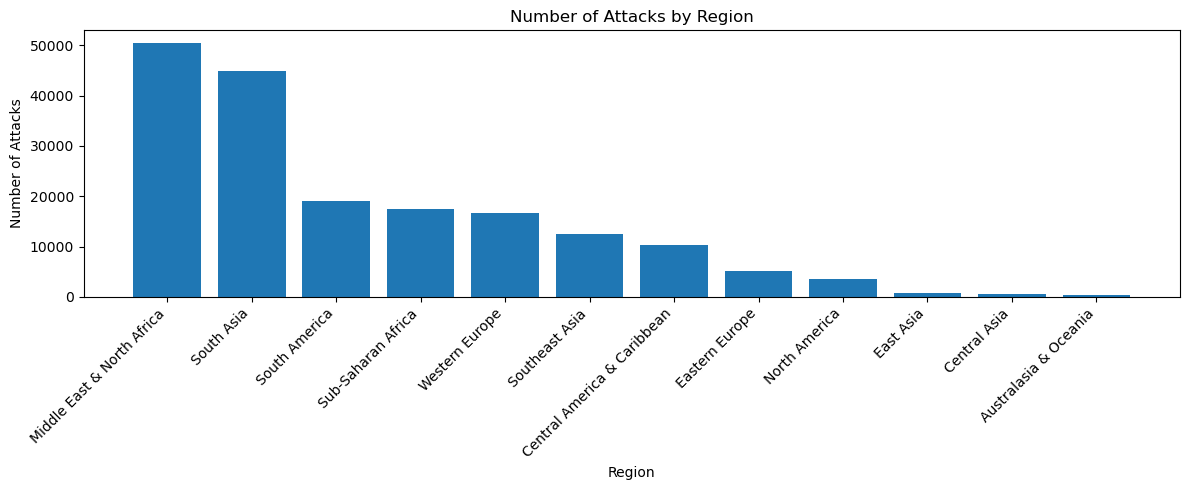

<Figure size 1200x500 with 0 Axes>

In [37]:
# 7.1 — Attacks by Region
counts = df['region_txt'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Number of Attacks by Region")
plt.xlabel("Region")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig("gtd_images/07_1_attacks_by_region.png", dpi=150, bbox_inches='tight')

### 📊 Attacks by Region — Conclusion

- **Middle East & North Africa** is the most affected region with **50,000+ attacks**
- **South Asia** (India, Pakistan, Afghanistan) follows closely with **45,000+ attacks**
- **Australasia & Oceania** is the safest region with barely any attacks
- Surprisingly **Western Europe** has more attacks than **Southeast Asia**

> *"The regions that can least afford war — are the ones suffering from it the most"*

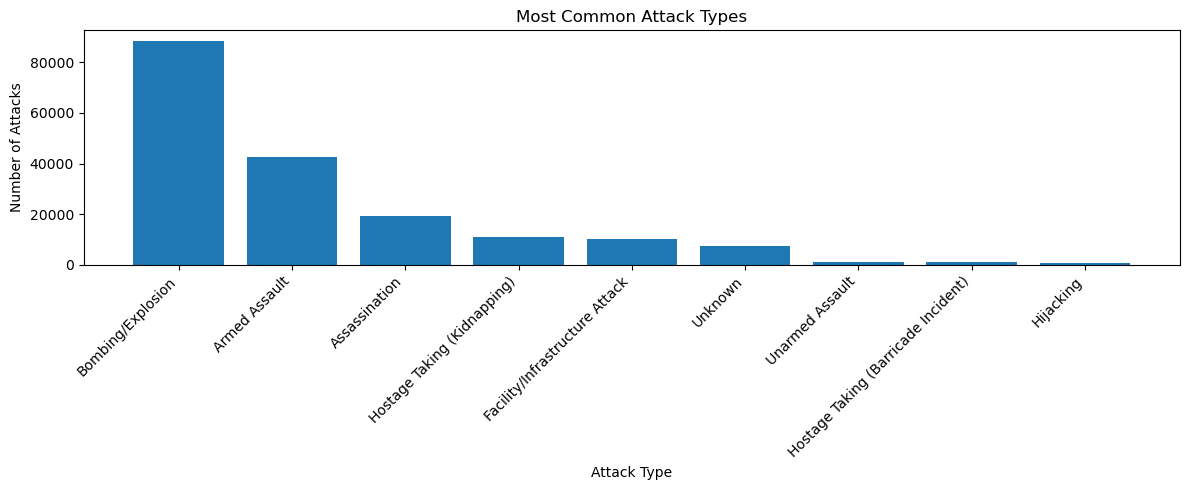

In [38]:
# 7.2 — Most Common Attack Types
counts = df['attacktype1_txt'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Most Common Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("gtd_images/07_2_attack_types.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Most Common Attack Types — Conclusion

- **Bombing/Explosion** is the most common attack type with **85,000+ attacks**
- **Armed Assault** follows with **42,000+ attacks**
- **Hijacking** is the rarest form of attack
- Bombs are the weapon of choice — cheap, deadly and cause maximum fear among civilians

> *"Every bomb that explodes — was once a choice. Peace is a choice too."*

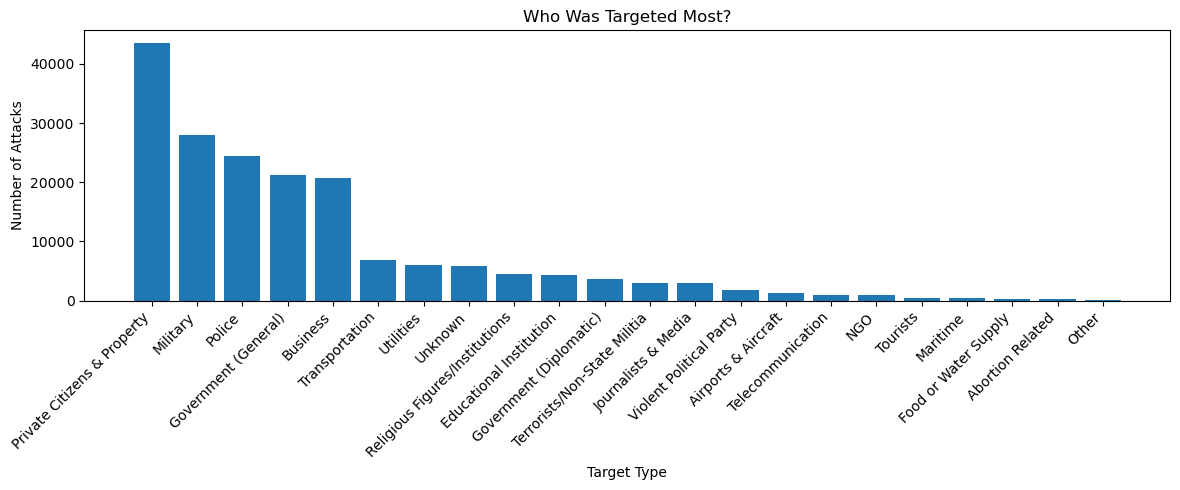

In [39]:
# 7.3 — Who Was Targeted Most?
counts = df['targtype1_txt'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Who Was Targeted Most?")
plt.xlabel("Target Type")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("gtd_images/07_3_target_types.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Who Was Targeted Most? — Conclusion

- **Private Citizens & Property** are the most targeted with **43,000+ attacks**
- **Military** and **Police** follow — but ordinary people suffer the most
- Even **Religious Figures, Educational Institutions and Food/Water Supply** were targeted
- War does not discriminate — it destroys the lives of innocent civilians first

> *"Terrorists don't fight armies — they terrorize ordinary people like you and me"*

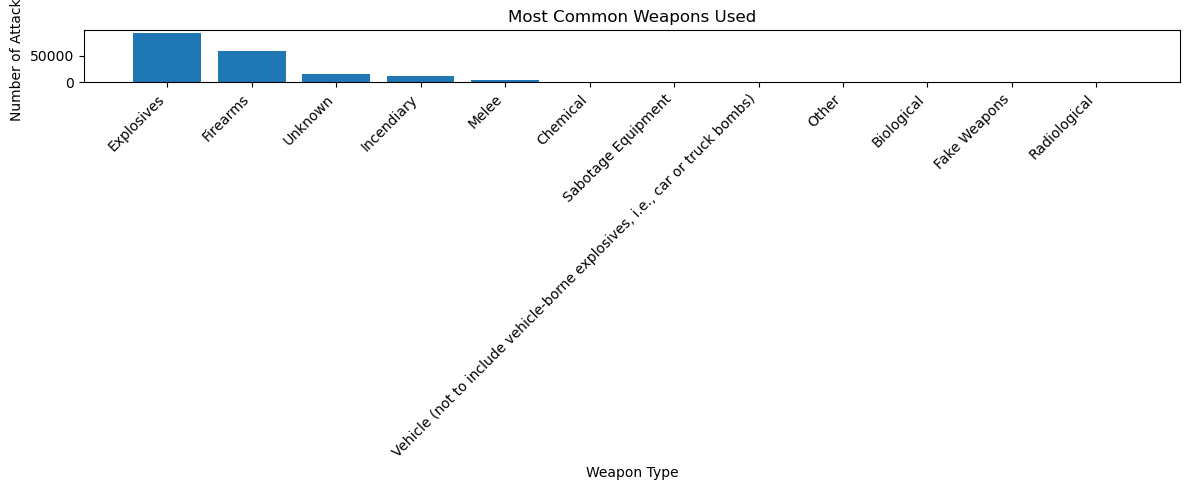

In [40]:
# 7.4 — Most Common Weapons Used
counts = df['weaptype1_txt'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Most Common Weapons Used")
plt.xlabel("Weapon Type")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("gtd_images/07_4_weapon_types.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Most Common Weapons Used — Conclusion

- **Explosives** dominate with **70,000+ attacks** — confirming our attack type finding
- **Firearms** follow with **50,000+ attacks**
- **Biological, Radiological and Fake Weapons** are extremely rare
- Explosives are cheap, easy to make and cause maximum destruction to life and property

> *"The most destructive weapons in history were built by brilliant minds — imagine what those minds could have built instead"*

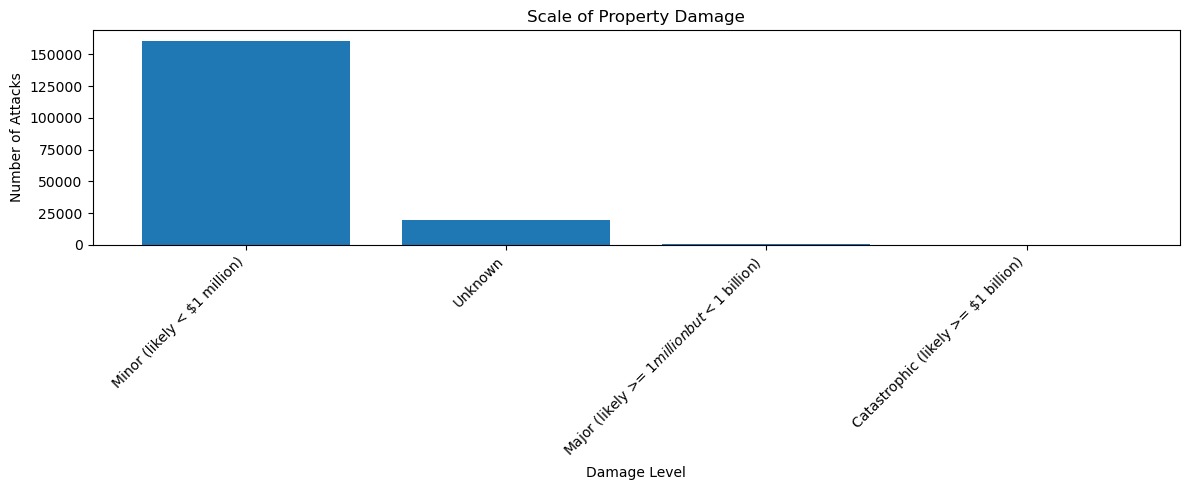

In [41]:
# 7.5 — Scale of Property Damage
counts = df['propextent_txt'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Scale of Property Damage")
plt.xlabel("Damage Level")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("gtd_images/07_5_property_damage.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Scale of Property Damage — Conclusion

- **Most attacks cause Minor damage** (< $1 million) — small local attacks dominate
- **Only 6 attacks** caused **Catastrophic damage** (≥ $1 billion) — but those 6 changed the world
- Even "Minor" damage to a poor family means losing their home, shop or livelihood forever
- The true economic cost of terrorism goes far beyond what money can measure

> *"To a poor family — a minor attack is always catastrophic"*

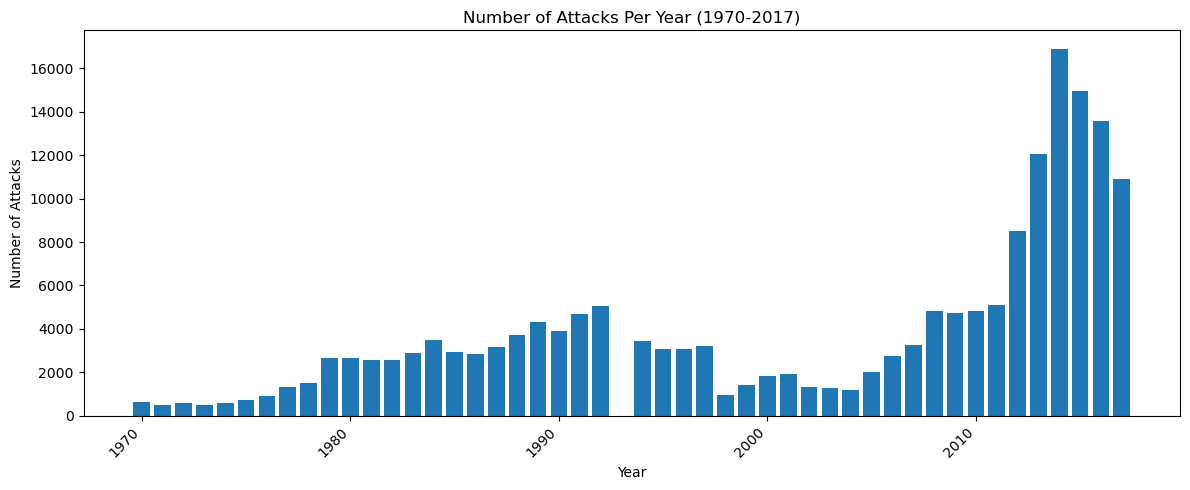

In [42]:
# 7.6 — Attacks Per Year (1970-2017)
counts = df['iyear'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title("Number of Attacks Per Year (1970-2017)")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("gtd_images/07_6_attacks_per_year.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Attacks Per Year (1970-2017) — Conclusion

- **1970s** — Terrorism was just beginning, very few attacks globally
- **1980s** — Steady growth as extremist groups started organizing
- **1990s** — Peak before a sudden drop — Cold War ending changed global dynamics
- **2000-2010** — Relatively stable period
- **After 2010** — Massive explosion 📈 peaking at **16,000+ attacks in 2014**
- The rise of ISIS and other extremist groups after 2010 caused the biggest surge in terrorism history

> *"It took humans 40 years to reach 5000 attacks per year — and only 4 more years to triple that number"*

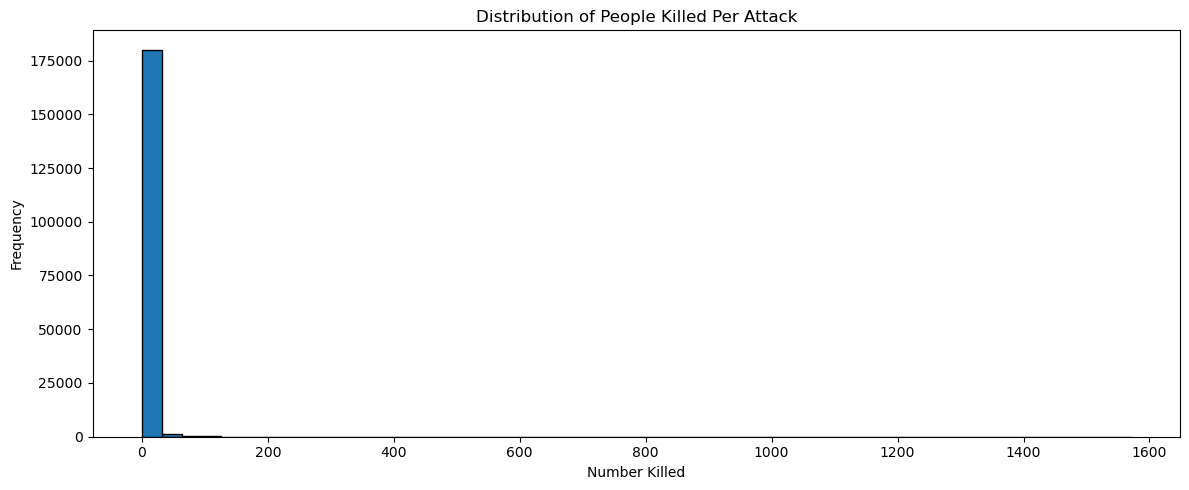

In [43]:
# 7.7 — Distribution of People Killed
plt.hist(df['nkill'], bins=50, edgecolor='black')
plt.title("Distribution of People Killed Per Attack")
plt.xlabel("Number Killed")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("gtd_images/07_7_kills_histogram.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Distribution of People Killed Per Attack — Conclusion

- Distribution is **extremely right skewed**
- **Most attacks kill very few people** (0-50) — concentrated at left
- **Rare but catastrophic attacks** kill 500-1600 people — the long tail on right
- This is why median is better than mean for this column — outliers like 9/11 distort the average

> *"Most attacks kill quietly — a few, one by one. But the world only remembers the ones that killed thousands"*

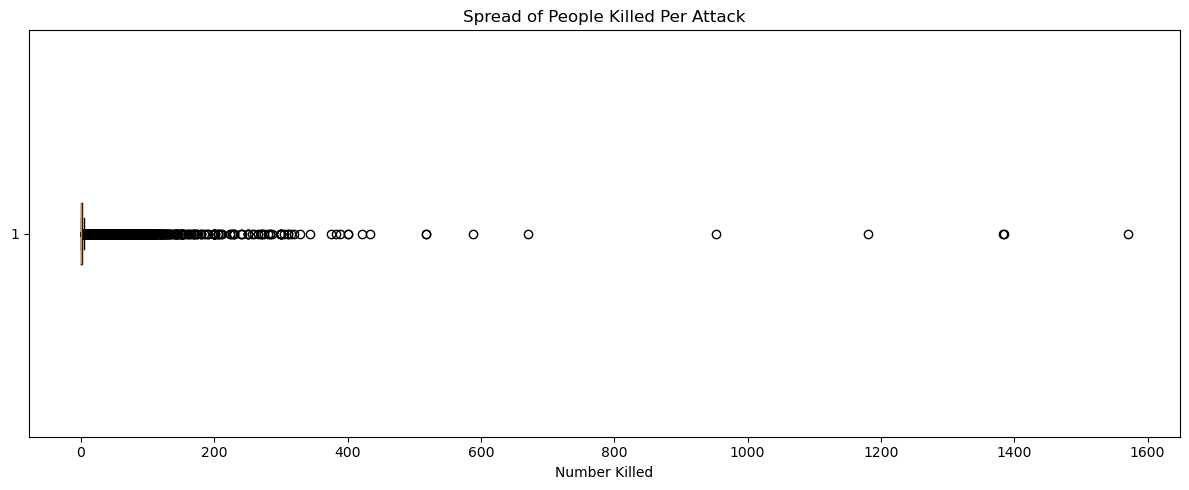

In [44]:
# 7.8 — Boxplot of People Killed
plt.boxplot(df['nkill'], vert=False)
plt.title("Spread of People Killed Per Attack")
plt.xlabel("Number Killed")
plt.tight_layout()
plt.savefig("gtd_images/07_8_kills_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Spread of People Killed Per Attack — Conclusion

- The **median is extremely close to 0** — most attacks kill very few people
- **Massive outliers** stretch all the way to 1600 — these are mega attacks like 9/11
- The box itself is tiny — but the dots tell the real story of catastrophic attacks
- Confirms our histogram finding — terrorism is mostly small scale but occasionally devastating

> *"A few attacks changed the entire world — and we are still living in their shadow"*

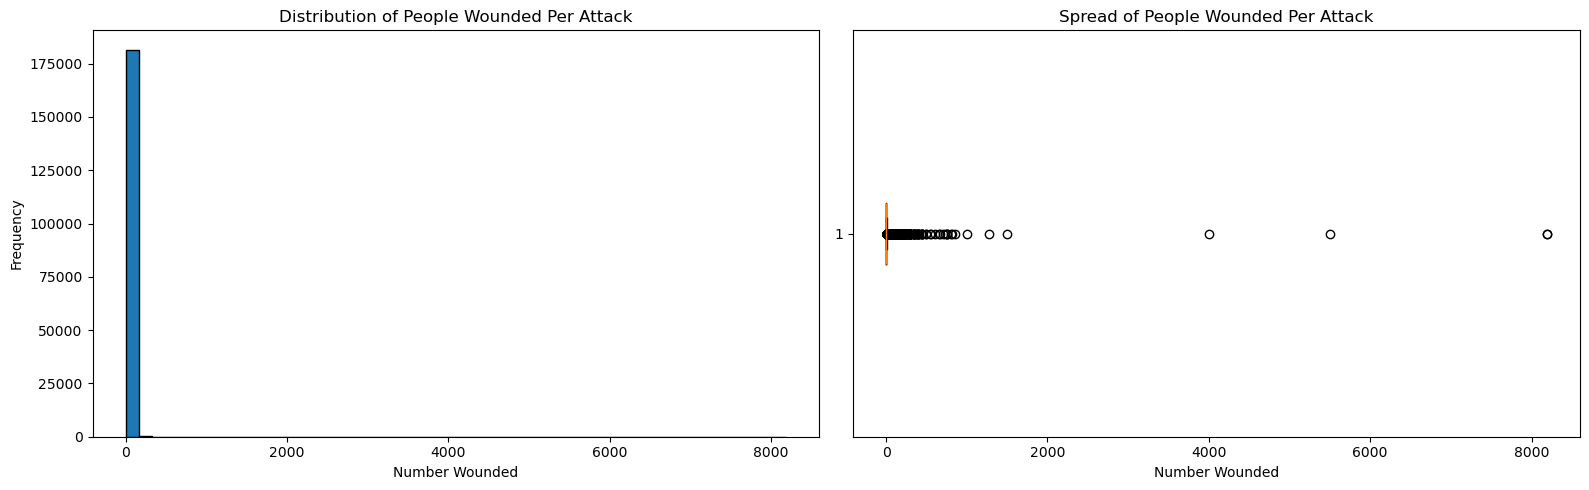

In [45]:
# 7.9 & 7.10 — Distribution and Spread of People Wounded
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df['nwound'], bins=50, edgecolor='black')
axes[0].set_title("Distribution of People Wounded Per Attack")
axes[0].set_xlabel("Number Wounded")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(df['nwound'], vert=False)
axes[1].set_title("Spread of People Wounded Per Attack")
axes[1].set_xlabel("Number Wounded")

plt.tight_layout()
plt.savefig("gtd_images/07_9_10_wounds.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Distribution and Spread of People Wounded Per Attack — Conclusion

- Same **extreme right skew** as kills — most attacks wound very few people
- **Median is close to 0** — majority of attacks cause minimal casualties
- But outliers stretch to **8000+ wounded** in a single attack — far more than kills!
- A few mega attacks wounded more people than thousands of small attacks combined
- Wounds are often worse than death — survivors carry physical and mental scars forever

> *"Behind every number is a person who survived — but was never the same again"*

## Step 8 — Bivariate Analysis

In [48]:
# 8.1 — Region vs Success (Chi-square Test)
ct = pd.crosstab(df['region_txt'], df['success'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square Test — Region vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Region DOES affect attack success")
else:
    print("Result: Independent ❌ — Region does NOT affect attack success")

Chi-square Test — Region vs Success
p-value: 0.0
Result: Dependent ✅ — Region DOES affect attack success


In [49]:
# 8.2 — Attack Type vs Success (Chi-square Test)
ct = pd.crosstab(df['attacktype1_txt'], df['success'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square Test — Attack Type vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Attack Type DOES affect attack success")
else:
    print("Result: Independent ❌ — Attack Type does NOT affect attack success")

Chi-square Test — Attack Type vs Success
p-value: 0.0
Result: Dependent ✅ — Attack Type DOES affect attack success


In [50]:
# 8.3 — Target Type vs Success (Chi-square Test)
ct = pd.crosstab(df['targtype1_txt'], df['success'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square Test — Target Type vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Target Type DOES affect attack success")
else:
    print("Result: Independent ❌ — Target Type does NOT affect attack success")

Chi-square Test — Target Type vs Success
p-value: 0.0
Result: Dependent ✅ — Target Type DOES affect attack success


In [51]:
# 8.4 — Weapon Type vs Success (Chi-square Test)
ct = pd.crosstab(df['weaptype1_txt'], df['success'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square Test — Weapon Type vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Weapon Type DOES affect attack success")
else:
    print("Result: Independent ❌ — Weapon Type does NOT affect attack success")

Chi-square Test — Weapon Type vs Success
p-value: 0.0
Result: Dependent ✅ — Weapon Type DOES affect attack success


In [52]:
# 8.5 — Suicide Attack vs Success (Chi-square Test)
ct = pd.crosstab(df['suicide'], df['success'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square Test — Suicide Attack vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Suicide attacks DOES affect attack success")
else:
    print("Result: Independent ❌ — Suicide attacks does NOT affect attack success")

Chi-square Test — Suicide Attack vs Success
p-value: 3.9506778024479746e-40
Result: Dependent ✅ — Suicide attacks DOES affect attack success


In [53]:
# 8.6 — People Killed vs Success (ANOVA Test)
group0 = df[df['success'] == 0]['nkill']
group1 = df[df['success'] == 1]['nkill']
f, p = f_oneway(group0, group1)
print("ANOVA Test — People Killed vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Number killed DOES affect attack success")
else:
    print("Result: Independent ❌ — Number killed does NOT affect attack success")

ANOVA Test — People Killed vs Success
p-value: 2.087361307267636e-99
Result: Dependent ✅ — Number killed DOES affect attack success


In [54]:
# 8.7 — People Wounded vs Success (ANOVA Test)
group0 = df[df['success'] == 0]['nwound']
group1 = df[df['success'] == 1]['nwound']
f, p = f_oneway(group0, group1)
print("ANOVA Test — People Wounded vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Number wounded DOES affect attack success")
else:
    print("Result: Independent ❌ — Number wounded does NOT affect attack success")

ANOVA Test — People Wounded vs Success
p-value: 2.4606717971894573e-23
Result: Dependent ✅ — Number wounded DOES affect attack success


## Step 8 — Bivariate Analysis — Summary

### Chi-square Tests (Categorical vs Target)

| Column | p-value | Result |
|---|---|---|
| Region vs Success | 0.0 | Dependent ✅ |
| Attack Type vs Success | 0.0 | Dependent ✅ |
| Target Type vs Success | 0.0 | Dependent ✅ |
| Weapon Type vs Success | 0.0 | Dependent ✅ |
| Suicide vs Success | 3.95e-40 | Dependent ✅ |

### ANOVA Tests (Numerical vs Target)

| Column | p-value | Result |
|---|---|---|
| People Killed vs Success | 2.08e-99 | Dependent ✅ |
| People Wounded vs Success | 2.46e-23 | Dependent ✅ |

### 🔍 Key Finding
- **Every single column is dependent on success**
- Region, weapon, target type, suicide — all affect whether an attack succeeds
- More kills and wounds = higher chance of success
- This is opposite to our AI Job dataset where nothing was dependent — because THIS is real data! 

> *"Real data tells real stories — and this one is devastating"*

In [55]:
# 8.8 — Property Damage vs Success (Chi-square Test)
ct = pd.crosstab(df['property'], df['success'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-square Test — Property Damage vs Success")
print("p-value:", p)
if p < 0.05:
    print("Result: Dependent ✅ — Property damage DOES affect attack success")
else:
    print("Result: Independent ❌ — Property damage does NOT affect attack success")

Chi-square Test — Property Damage vs Success
p-value: 0.0
Result: Dependent ✅ — Property damage DOES affect attack success


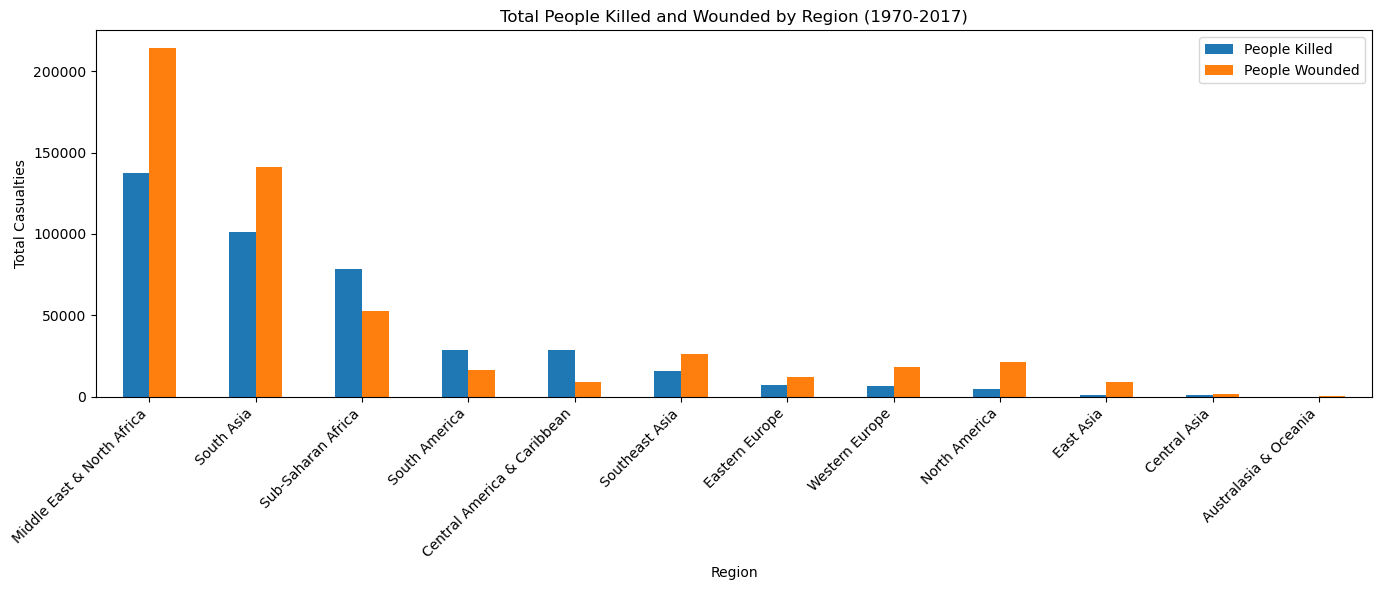

In [56]:
# 8.9 — Total Casualties by Region (Human Cost)
region_casualties = df.groupby('region_txt')[['nkill', 'nwound']].sum()
region_casualties = region_casualties.sort_values('nkill', ascending=False)

region_casualties.plot(kind='bar', figsize=(14, 6))
plt.title("Total People Killed and Wounded by Region (1970-2017)")
plt.xlabel("Region")
plt.ylabel("Total Casualties")
plt.xticks(rotation=45, ha='right')
plt.legend(['People Killed', 'People Wounded'])
plt.tight_layout()
plt.savefig("gtd_images/08_9_casualties_by_region.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Total Casualties by Region — Conclusion

- **Middle East & North Africa** suffered the most — **1,37,000+ killed and 2,15,000+ wounded**
- **South Asia** follows — **1,00,000+ killed and 1,40,000+ wounded**
- **Sub-Saharan Africa** third — **80,000+ killed**
- These three regions are already among the poorest in the world — yet they bear the heaviest cost of terrorism
- **Australasia & Oceania** barely visible — safest region

> *"The poorest regions of the world pay the heaviest price for wars they did not choose"*

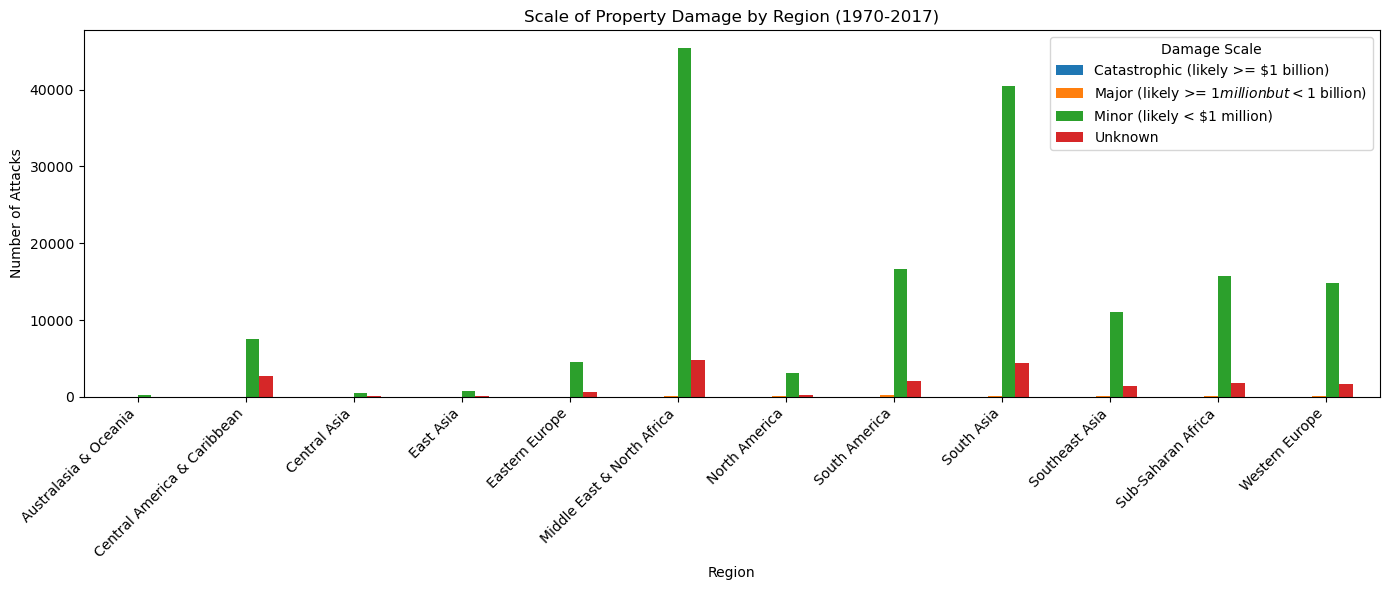

In [57]:
# 8.10 — Property Damage Scale by Region
ct = pd.crosstab(df['region_txt'], df['propextent_txt'])
ct.plot(kind='bar', figsize=(14, 6))
plt.title("Scale of Property Damage by Region (1970-2017)")
plt.xlabel("Region")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Damage Scale')
plt.tight_layout()
plt.savefig("gtd_images/08_10_property_damage_region.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Scale of Property Damage by Region — Conclusion

- **Middle East & North Africa** and **South Asia** have the highest property damage
- **Minor damage dominates** everywhere — thousands of small attacks destroying civilian homes, shops and infrastructure
- These are not military targets — ordinary people lose everything they own
- Even "minor" damage of $1 million destroys entire villages in poor regions

> *"Every destroyed home was someone's lifetime of savings — every bombed market was someone's livelihood"*

## Step 9 — Multivariate Analysis

In [58]:
# 9.1 — Correlation Matrix
corr = df[['iyear', 'imonth', 'nkill', 'nwound', 'nkillter', 'property', 'suicide', 'success']].corr()
print(corr)

             iyear    imonth     nkill    nwound  nkillter  property  \
iyear     1.000000  0.000139  0.021252  0.017484  0.072788 -0.278916   
imonth    0.000139  1.000000  0.004031  0.003178  0.002720 -0.005816   
nkill     0.021252  0.004031  1.000000  0.443326  0.348846 -0.016816   
nwound    0.017484  0.003178  0.443326  1.000000  0.027915 -0.012557   
nkillter  0.072788  0.002720  0.348846  0.027915  1.000000 -0.045152   
property -0.278916 -0.005816 -0.016816 -0.012557 -0.045152  1.000000   
suicide   0.137736  0.003071  0.136385  0.096101  0.106118 -0.073382   
success  -0.082963 -0.002845  0.049619  0.023346 -0.021856 -0.036876   

           suicide   success  
iyear     0.137736 -0.082963  
imonth    0.003071 -0.002845  
nkill     0.136385  0.049619  
nwound    0.096101  0.023346  
nkillter  0.106118 -0.021856  
property -0.073382 -0.036876  
suicide   1.000000 -0.031155  
success  -0.031155  1.000000  


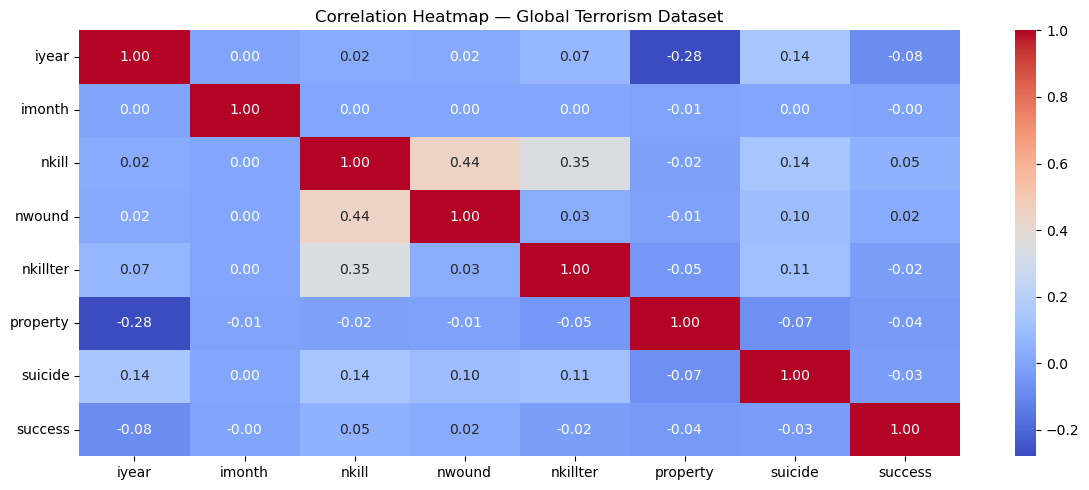

In [59]:
# 9.2 — Correlation Heatmap
corr = df[['iyear', 'imonth', 'nkill', 'nwound', 'nkillter', 'property', 'suicide', 'success']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap — Global Terrorism Dataset")
plt.tight_layout()
plt.savefig("gtd_images/09_1_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Correlation Heatmap — Conclusion

- **nkill and nwound** have strongest correlation (0.44) — attacks that kill more also wound more
- **nkill and nkillter** correlated (0.35) — deadlier attacks also kill more attackers
- **iyear and property** negatively correlated (-0.28) — older attacks caused more property damage than recent ones
- **success** shows weak correlation with all columns — success depends on categorical factors more than numbers

> *"The deadlier the attack — the more destruction it leaves behind in every direction"*


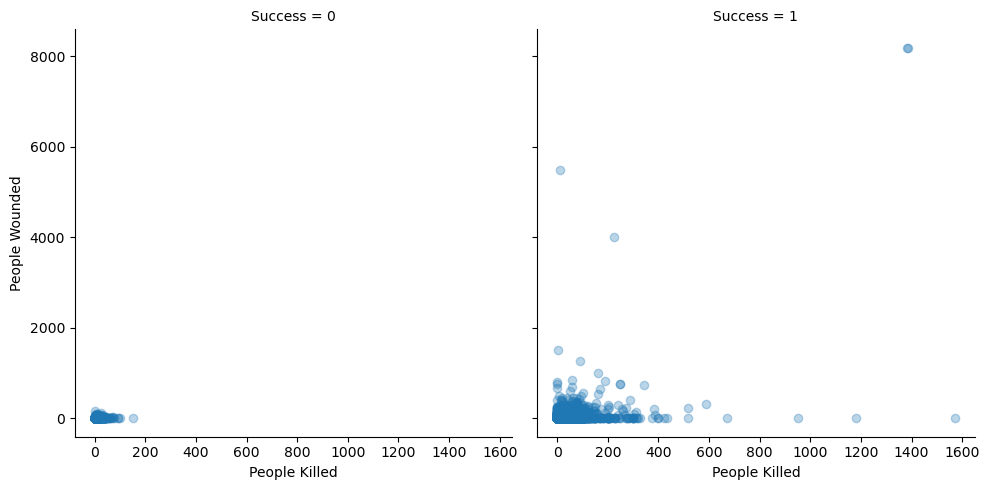

In [60]:
# 9.2 — Scatter Plot: nkill vs nwound by Success
g = sns.FacetGrid(df, col='success', height=5)
g.map(plt.scatter, 'nkill', 'nwound', alpha=0.3)
g.set_axis_labels("People Killed", "People Wounded")
g.set_titles(col_template="Success = {col_name}")
plt.tight_layout()
plt.savefig("gtd_images/09_2_scatter_kill_wound.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Scatter Plot — Kills vs Wounded by Success — Conclusion

- **Failed attacks (0)** — clustered near zero, minimal casualties
- **Successful attacks (1)** — spread wide with extreme outliers reaching 1600 killed and 8000 wounded
- Most successful attacks still kill few people — but the outliers are devastating
- The gap between failed and successful attacks tells the true cost of security failures

> *"Every successful attack that could have been stopped — represents a security failure that cost innocent lives"*

## Step 10 — Conclusions & The Case for World Peace

### 🔍 What the Data Told Us

| Finding | Insight |
|---|---|
| 1,81,691 attacks in 47 years | Terrorism never stopped — it only grew |
| Middle East & South Asia suffered most | Poorest regions pay the heaviest price |
| Civilians are the #1 target | War was never about armies — it was always about ordinary people |
| Bombing is the most common attack | Cheap, accessible and maximally destructive |
| Attacks exploded after 2010 | The world became MORE dangerous, not less |
| 4,11,868 people killed | Nearly half a million lives lost forever |
| 5,23,869 people wounded | Survivors carry scars for the rest of their lives |
| Every column dependent on success | Region, weapon, target — everything matters |

---

### 💰 The Real Economic Cost

The true cost of terrorism goes far beyond what this dataset captures.

According to global estimates — the **War on Terror alone cost $8 trillion** between 2001-2021.

**With $8 trillion we could have:**
- 🏫 Built **80 lakh schools** across the developing world
- 🏥 Built **40 lakh hospitals** in regions with no healthcare
- 💧 Provided **clean drinking water** to every person on earth
- ⚡ Powered **entire continents** with renewable energy
- 🌾 Ended **world hunger** for the next 50 years

---

### 🕊️ The Case for World Peace

> *"The money spent on one day of war could fund education for an entire generation"*

> *"4,11,868 people didn't die in this dataset — they were fathers, mothers, children and dreamers"*

> *"The regions that can least afford war — suffer from it the most"*

> *"Every bomb that was built — was a school that was never constructed"*

---

### 🌍 Final Message

This analysis was not just an exercise in data science.

It is a reminder that **behind every row in this dataset is a human story** — a family destroyed, a village burned, a child who never got to grow up.

Data science gives us the power to see patterns — and the pattern here is clear.

**War has never built anything. Peace does.**

*— Prasanna Wankhede